In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RUNS = Path("runs_e13")
RECS = {json.load(open(p))["generator"]: json.load(open(p)) for p in sorted(RUNS.glob("*.json"))}
VER = json.load(open("e13_verify.json"))
PG = VER["summary"]["per_gen_worst"]

C = {"robust": "#27ae60", "nonunif": "#e67e22", "both": "#c0392b", "recovery": "#8e44ad",
     "bound": "#2980b9", "oracle": "#7f8c8d"}
def route_color(r): return {"neither": C["robust"], "nonuniformity": C["nonunif"],
                            "both": C["both"], "recovery": C["recovery"]}[r]
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
print(f"generators: {len(RECS)} | Theorem-2 cells: {VER['summary']['n_thm2_hold']}/{VER['summary']['n_cells']}")

generators: 19 | Theorem-2 cells: 76/76


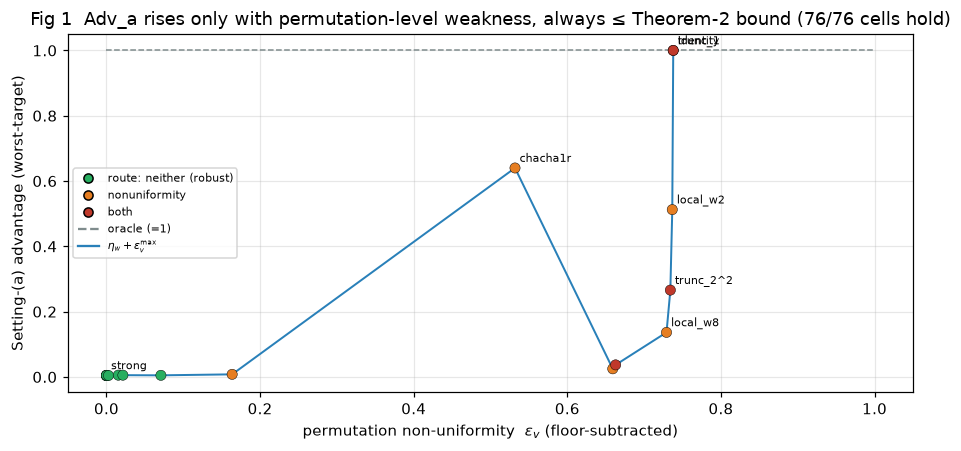

In [2]:
gens = sorted(PG.values(), key=lambda r: r["eps_v_above_floor"])
x = [r["eps_v_above_floor"] for r in gens]
adv_a = [r["adv_a"] for r in gens]
rhs = [r["thm2_rhs"] for r in gens]
cols = [route_color(r["route"]) for r in gens]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot([0, 1], [1, 1], "--", color=C["oracle"], lw=1, label="Setting-(b) oracle (=1)")
order = np.argsort(x)
ax.plot(np.array(x)[order], np.array(rhs)[order], "-", color=C["bound"], lw=1.3,
        label=r"Theorem-2 bound  $\eta_w+\varepsilon_v^{\max}$")
ax.scatter(x, adv_a, c=cols, s=45, zorder=3, edgecolor="k", linewidth=0.3)
for r in gens:
    if r["adv_a"] > 0.1 or r["generator"] in ("strong", "chacha1r", "trunc_1"):
        ax.annotate(r["generator"], (r["eps_v_above_floor"], r["adv_a"]),
                    fontsize=7, xytext=(3, 4), textcoords="offset points")
ax.set_xlabel(r"permutation non-uniformity  $\varepsilon_v$ (floor-subtracted)")
ax.set_ylabel("Setting-(a) advantage (worst-target)")
ax.set_title("Fig 1  Adv_a rises only with permutation-level weakness, always ≤ Theorem-2 bound "
             "(76/76 cells hold)")
from matplotlib.lines import Line2D
leg = [Line2D([0],[0],marker='o',ls='',mfc=C["robust"],mec='k',label='route: neither (robust)'),
       Line2D([0],[0],marker='o',ls='',mfc=C["nonunif"],mec='k',label='nonuniformity'),
       Line2D([0],[0],marker='o',ls='',mfc=C["both"],mec='k',label='both'),
       Line2D([0],[0],ls='--',color=C["oracle"],label='oracle (=1)'),
       Line2D([0],[0],color=C["bound"],label=r'$\eta_w+\varepsilon_v^{\max}$')]
ax.legend(handles=leg, fontsize=7, loc="center left")
plt.tight_layout(); plt.show()

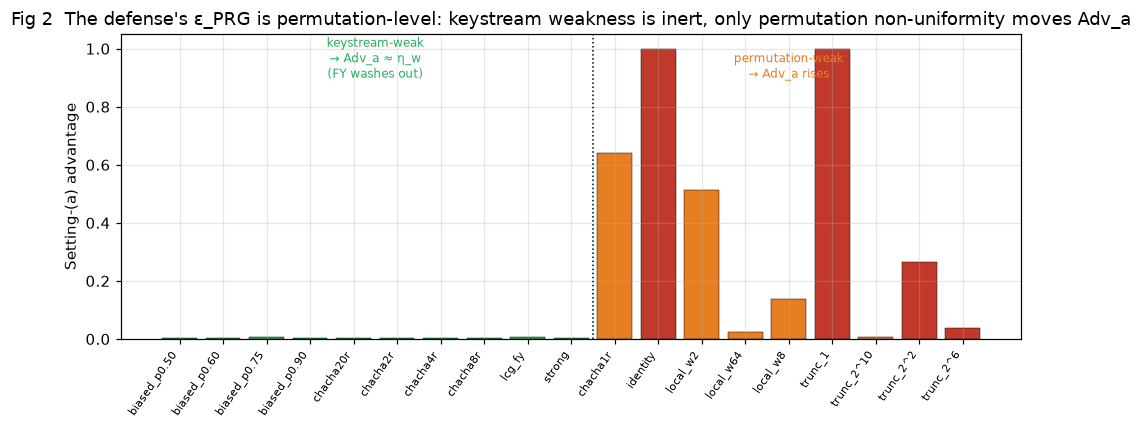

In [3]:
ks = VER["summary"]["keystream_robust_generators"]
pw = VER["summary"]["permutation_weak_generators"]
names = ks + pw
advs = [PG[g]["adv_a"] for g in names]
epss = [PG[g]["eps_v_above_floor"] for g in names]
cols = [C["robust"]]*len(ks) + [route_color(PG[g]["route"]) for g in pw]

fig, ax = plt.subplots(figsize=(9, 4))
xpos = np.arange(len(names))
ax.bar(xpos, advs, color=cols, edgecolor="k", linewidth=0.3)
ax.axvline(len(ks) - 0.5, color="k", ls=":", lw=1)
ax.text(len(ks)/2 - 0.5, 0.9, "keystream-weak\n→ Adv_a ≈ η_w\n(FY washes out)",
        ha="center", fontsize=8, color=C["robust"])
ax.text(len(ks) + len(pw)/2 - 0.5, 0.9, "permutation-weak\n→ Adv_a rises",
        ha="center", fontsize=8, color=C["nonunif"])
ax.set_xticks(xpos); ax.set_xticklabels(names, rotation=55, ha="right", fontsize=7)
ax.set_ylabel("Setting-(a) advantage"); ax.set_ylim(0, 1.05)
ax.set_title("Fig 2  The defense's ε_PRG is permutation-level: keystream weakness is inert, "
             "only permutation non-uniformity moves Adv_a")
plt.tight_layout(); plt.show()

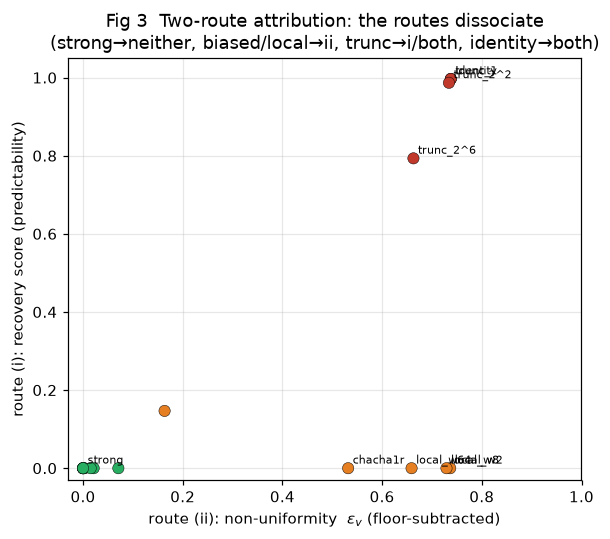

§8.5-E13 LEDGER
Theorem 2 (Adv_a ≤ η_w + ε_v^max): holds 76/76 cells → grid-wide
anchor strong:   Adv_a=0.053 ≈ η_w=0.040  (robust) ✓
anchor identity: Adv_a=1.00 = Adv_b(oracle)=1.00  (Setting-a=Setting-b collapse) ✓
robust to keystream weakness: 10 generators (reduced-round≥2, LCG, biased bits) — FY washes them out
sensitive to permutation weakness: 9 generators (1-round ChaCha, tiny keyspace, local shuffle, identity)
VERDICT: no PPT attack beats the Setting-(a) baseline at a sound PRG; when the PERMUTATION is
weakened, Adv_a tracks ε_PRG as Theorem 2 predicts, always within η_w + ε_v^max.


In [4]:
rec = [PG[g]["recover_score"] for g in PG]
nu = [PG[g]["eps_v_above_floor"] for g in PG]
cols = [route_color(PG[g]["route"]) for g in PG]
fig, ax = plt.subplots(figsize=(5.6, 5))
ax.scatter(nu, rec, c=cols, s=55, edgecolor="k", linewidth=0.3, zorder=3)
for g in PG:
    if PG[g]["recover_score"] > 0.3 or PG[g]["eps_v_above_floor"] > 0.5 or g == "strong":
        ax.annotate(g, (PG[g]["eps_v_above_floor"], PG[g]["recover_score"]),
                    fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel(r"route (ii): non-uniformity  $\varepsilon_v$ (floor-subtracted)")
ax.set_ylabel("route (i): recovery score (predictability)")
ax.set_title("Fig 3  Two-route attribution: the routes dissociate\n(strong→neither, biased/local→ii, "
             "trunc→i/both, identity→both)")
ax.set_xlim(-0.03, 1); ax.set_ylim(-0.03, 1.05); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

s = VER["summary"]
print("="*66); print("§8.5-E13 LEDGER"); print("="*66)
print(f"Theorem 2 (Adv_a ≤ η_w + ε_v^max): holds {s['n_thm2_hold']}/{s['n_cells']} cells → grid-wide")
print(f"anchor strong:   Adv_a={s['strong_adv_a']:.3f} ≈ η_w={s['strong_eta_w']:.3f}  (robust) ✓")
print(f"anchor identity: Adv_a={s['identity_adv_a']:.2f} = Adv_b(oracle)={s['identity_adv_b']:.2f}  "
      f"(Setting-a=Setting-b collapse) ✓")
print(f"robust to keystream weakness: {len(s['keystream_robust_generators'])} generators "
      f"(reduced-round≥2, LCG, biased bits) — FY washes them out")
print(f"sensitive to permutation weakness: {len(s['permutation_weak_generators'])} generators "
      f"(1-round ChaCha, tiny keyspace, local shuffle, identity)")
print("VERDICT: no PPT attack beats the Setting-(a) baseline at a sound PRG; when the PERMUTATION is")
print("weakened, Adv_a tracks ε_PRG as Theorem 2 predicts, always within η_w + ε_v^max.")